# Optic flow task


This notebook illustrates the optic flow task and how to use it with our pretrained fly visual system model and decoder.

**Select GPU runtime**

To run the notebook on a GPU select Menu -> Runtime -> Change runtime type -> GPU.

In [3]:
# @markdown **Check access to GPU**

try:
    import google.colab

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if True:
    import torch

    try:
        cuda_name = torch.cuda.get_device_name()
        print(f"Name of the assigned GPU / CUDA device: {cuda_name}")
    except RuntimeError:
        import warnings

        warnings.warn(
            "You have not selected Runtime Type: 'GPU' or Google could not assign you one. Please revisit the settings as described above or proceed on CPU (slow)."
        )

Name of the assigned GPU / CUDA device: NVIDIA GeForce RTX 2080


**Install Flyvis**

The notebook requires installing our package `flyvis`. You may need to restart your session after running the code block below with Menu -> Runtime -> Restart session. Then, imports from `flyvis` should succeed without issue.

In [4]:
# @markdown **Install Flyvis**
if IN_COLAB:
    !git clone https://github.com/TuragaLab/flyvis.git
    %cd /content/flyvis
    !pip install -e .[examples]

# The Sintel dataset

We use the Sintel dataset to train our models as described in the paper. More infos about the Sintel dataset can be found on the official Sintel website: http://sintel.is.tue.mpg.de/.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch

from flyvis.datasets.sintel import MultiTaskSintel
from flyvis.analysis.animations.sintel import SintelSample
from flyvis.datasets.FT3D import MultiTaskFlyingThings3D
from flyvis.analysis.animations.FT3D import FT3DSample

The class `MultiTaskSintel` loads, preprocesses, renders, and augments the sintel data. It adheres to the pytorch dataset primitive. It provides the interface to the input data and the output data for the flyvis networks. Note: the fly-eye rendering we use here, we introduce in the notebook on creating custom stimuli already.

This is the full setting:

In [2]:
dataset = MultiTaskSintel(
    tasks=["flow"],
    boxfilter=dict(extent=15, kernel_size=13),
    # Because the fly eye rendering is square
    # and sintel is wide, we can crop sintel
    # in width and render three sequences from one.
    # This allows us to statically augment our dataset
    # a bit already before we proceed with the random augmentations.
    # We end up with 3 * 23 sequences.
    vertical_splits=3,
    n_frames=19,
    center_crop_fraction=0.7,
    dt=1 / 50,
    augment=True,
    # From sequences with more than n_frames, we randomly sample the start frame.
    random_temporal_crop=True,
    all_frames=False,
    # We resample movie frames to the effective framerate given by 1/dt
    resampling=True,
    # We interpolate the flow arrows to 1/dt.
    interpolate=True,
    # We flip with equal probability (using one flip-axis).
    p_flip=0.5,
    flip_axes=[0, 1],
    # We rotate with equal probability (using five fold rotation symmetry of the hex-grid).
    p_rot=5 / 6,
    # We randomly adjust contrast and brightness.
    contrast_std=0.2,
    brightness_std=0.1,
    # We add random white noise pixelweise.
    gaussian_white_noise=0.08,
    gamma_std=None,
    _init_cache=True,
    unittest=False,
)
import os
from pathlib import Path
FT3D_ROOT      = Path(os.getenv("FT3D_ROOT", "/mnt/s/datasets/FlyingThings3D"))
augment = True
dataset1 = MultiTaskFlyingThings3D(
        ft3d_path=FT3D_ROOT,
        tasks=["rgb", "flow"],
        augment=augment,
        _init_cache=True,
    )

[2025-05-30 02:12:32] sintel_utils:331 Found Sintel at /home/z/flyvis/data/SintelDataSet


In [3]:
# The `dataset.arg_df` tracks the sequence index, identity etc.
#dataset.arg_df
dataset1.arg_df

,index,original_index,name,original_n_frames
0,0,0,sequence_00000_A_0000_split_00,9
1,1,0,sequence_00000_A_0000_split_01,9
2,2,0,sequence_00000_A_0000_split_02,9
3,3,1,sequence_00001_A_0001_split_00,9
4,4,1,sequence_00001_A_0001_split_01,9
...,...,...,...,...
4255,4255,2237,sequence_02237_C_0748_split_01,9
4256,4256,2237,sequence_02237_C_0748_split_02,9
4257,4257,2238,sequence_02238_C_0749_split_00,9
4258,4258,2238,sequence_02238_C_0749_split_01,9


## Single sample

First, let's chunk this into smaller digestable pieces.

In [13]:
dataset = MultiTaskSintel(
    tasks=["flow"],
    boxfilter=dict(extent=15, kernel_size=13),
    vertical_splits=1,
    dt=1 / 24,
    augment=False,
)

[2025-05-30 00:51:23] sintel_utils:331 Found Sintel at /home/z/flyvis/data/SintelDataSet


The first sample. For the target, the pixel-accurate motion vectors, the color indicates the direction of motion of the respective input pixel. The saturation indicates the magnitude of motion.

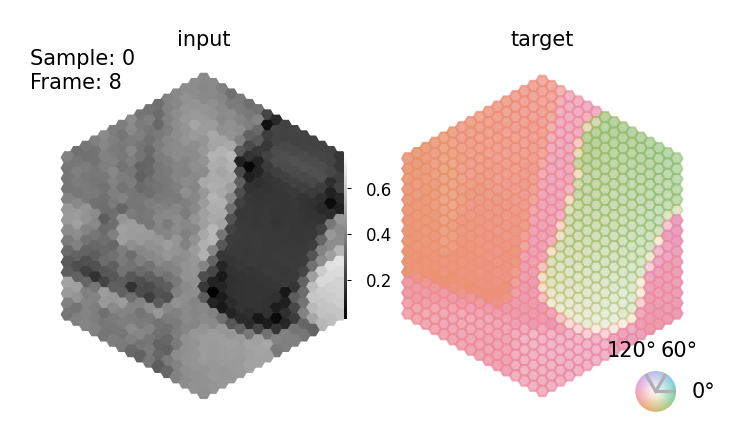

In [56]:
#lum = dataset[0]["lum"]
#flow = dataset[0]["flow"]

#animation = SintelSample(lum[None], flow[None])
#animation.animate_in_notebook()

lum = dataset1[2]["rgb"]
flow = dataset1[2]["flow"]

animation = SintelSample(lum[None], flow[None])
animation.animate_in_notebook()


Sintel has more groundtruth annotations. We support depth and flow because we know with some confidence that these are relevant for the fly.

In [ ]:
dataset = MultiTaskSintel(
    tasks=["depth"],
    boxfilter=dict(extent=15, kernel_size=13),
    vertical_splits=1,
    dt=1 / 24,
    augment=False,
)

In [ ]:
lum1 = dataset[0]["lum"]
depth1 = dataset[0]["depth"]

animation = SintelSample(lum1[None], depth1[None])
animation.animate_in_notebook()

# Augmenting the dataset step-by-step

We apply rich augmentations to the dataset of naturalistic sequences because the dataset is otherwise relatively small. This might lead to overfitting to, e.g., predicting motion mostly into well-represented directons or of objects of specific contrasts etc. Using rich augmentations, we 'ask' the network to generalize better and invariantly compute motion regardless of direction, contrast, brightness, pixel noise, temporal appearance etc.

## Vertical splits

First, we split each sequence into three sequences vertically to leverage a wider extent of the video than if we would only render the center. We precompute these renderings.

In [ ]:
from flyvis.analysis.visualization.plots import quick_hex_scatter

In [ ]:
dataset = MultiTaskSintel(
    tasks=["flow"],
    boxfilter=dict(extent=15, kernel_size=13),
    vertical_splits=3,
    dt=1 / 24,
    augment=False,
)

Sintel has 23 movie sequences originally.

In [ ]:
len(np.unique(dataset.arg_df.original_index))

Each original sequence is 436 pixel in height times 1024 pixel in width in cartesian coordinates.

In [ ]:
sequence = dataset.cartesian_sequence(0, vertical_splits=1, center_crop_fraction=1.0)
print(sequence.shape)

With the vertical crops, we end up with 3 * 23 sequences. The `dataset.arg_df` tracks the sequence index, identity etc.

In [ ]:
dataset.arg_df

In [ ]:
_ = plt.imshow(sequence[0, 0], cmap=plt.cm.binary_r)

In [ ]:
fig, axes = plt.subplots(1, 3)
_ = quick_hex_scatter(dataset[0]['lum'][0].flatten(), fig=fig, ax=axes[0], cbar=False)
_ = quick_hex_scatter(dataset[1]['lum'][0].flatten(), fig=fig, ax=axes[1], cbar=False)
_ = quick_hex_scatter(dataset[2]['lum'][0].flatten(), fig=fig, ax=axes[2], cbar=False)

## Random temporal crops

We train on 19 frames ~ 792ms movie. Most sequences have 49 frames. To use the whole temporal content, we stochastically sample start and end frame ~ ((1, 19), (2, 20), ..., (31, 49)).

In [ ]:
dataset = MultiTaskSintel(
    tasks=["flow"],
    boxfilter=dict(extent=15, kernel_size=13),
    vertical_splits=3,
    n_frames=19,
    dt=1 / 24,
    augment=True,
    random_temporal_crop=True,
    all_frames=False,
    resampling=False,
    interpolate=False,
    p_flip=0,
    p_rot=0,
    contrast_std=None,
    brightness_std=None,
    gaussian_white_noise=None,
)

In [ ]:
# These two samples from the same original sequence should have stochastically different start and end frames.
lum1 = dataset[0]['lum']
lum2 = dataset[0]['lum']

In [ ]:
animation = SintelSample(lum1[None], lum2[None], title2="input")
animation.animate_in_notebook()

## Flips and rotations

Next, we flip stochastically across 2 axes and or rotate a random number of times around the center. We implement this to be fast to do so at runtime.

In [ ]:
dataset = MultiTaskSintel(
    tasks=["flow"],
    boxfilter=dict(extent=15, kernel_size=13),
    vertical_splits=3,
    n_frames=19,
    dt=1 / 24,
    augment=True,
    random_temporal_crop=False,
    all_frames=False,
    resampling=False,
    interpolate=False,
    p_flip=1 / 2,
    p_rot=5 / 6,
    contrast_std=None,
    brightness_std=None,
    gaussian_white_noise=None,
)

In [ ]:
# These two samples from the same original sequence should have stochastically different orientation.
lum1 = dataset[0]['lum']
lum2 = dataset[0]['lum']

In [ ]:
animation = SintelSample(lum1[None], lum2[None], title2="input")
animation.animate_in_notebook()

Flow vectors need to be flipped and rotated accordingly.

In [ ]:
# These two samples from the same original sequence should have stochastically different orientation.
data = dataset[0]
lum1 = data['lum']
flow1 = data['flow']

In [ ]:
animation = SintelSample(lum1[None], flow1[None])
animation.animate_in_notebook()

## Further augmentations

Besides that, we also augment the input with random contrasts and brightnesses and random gaussian pixel noise, while the motion stays the same. This pretends that the same motion takes place under different illumination conditions and signal to noise ratios.  

In [ ]:
dataset = MultiTaskSintel(
    tasks=["flow"],
    boxfilter=dict(extent=15, kernel_size=13),
    vertical_splits=3,
    n_frames=19,
    dt=1 / 24,
    augment=True,
    random_temporal_crop=False,
    all_frames=False,
    resampling=False,
    interpolate=False,
    p_flip=0,
    p_rot=0,
    contrast_std=0.2,
    brightness_std=0.1,
    gaussian_white_noise=0.08,
)

In [ ]:
# These two samples from the same original sequence have
# stochastically different contrast, brightness and pixel-wise noise.
lum1 = dataset[0]['lum']
lum2 = dataset[0]['lum']

In [ ]:
animation = SintelSample(lum1[None], lum2[None], title2="input")
animation.animate_in_notebook()

# Framerate of the dataset and integration time step

The Sintel dataset is originally rendered at 24 frames per second, i.e., one frame every 42ms. The fruit fly neurons are able to respond to temporal differences as fast as 5-20ms. Therefore, we resample every frame multiple times to pretend that the movie was originally sampled at such a faster framerate. For the motion fields, we interpolate flow vectors in time instead of resampling them, which hopefully gives a better learning signal to the network. We have to trade-off speed of the numerical integration and memory consumption during optimization with the simulation accuracy by choosing time steps between 5-20ms. We chose to train networks at the upper bount of 20ms and evaluate them more accurately at 5-10ms.

In [ ]:
dataset = MultiTaskSintel(
    tasks=["flow"],
    boxfilter=dict(extent=15, kernel_size=13),
    vertical_splits=3,
    n_frames=19,
    dt=1 / 50,
    augment=False,
    resampling=True,
    interpolate=True,
)

In [ ]:
# Now, every input frame appears twice and target frames are interpolated.
data = dataset[0]
lum1 = data['lum']
flow1 = data['flow']

In [ ]:
animation = SintelSample(lum1[None], flow1[None])
animation.animate_in_notebook()

# Computing responses to the Sintel data

Before we get to training a network, we look at a few responses to these type of sequences of individual neurons.

In [14]:
from flyvis.network import NetworkView, Network
from flyvis.utils.activity_utils import LayerActivity

from flyvis.datasets.sintel import MultiTaskSintel

In [15]:
# new network instance
network = Network()

# Alternative: uncomment to use a pretrained network
# network_view = NetworkView(results_dir / "flow/0000/000")
# network = network_view.init_network(network)

[2025-05-30 03:11:13] network:222 Initialized network with NumberOfParams(free=734, fixed=2959) parameters.


In [16]:
layer_activity = LayerActivity(None, network.connectome, keepref=True)

In [20]:
dataset = MultiTaskSintel(
    tasks=["flow"],
    boxfilter=dict(extent=15, kernel_size=13),
    vertical_splits=1,
    n_frames=19,
    dt=1 / 50,
    augment=False,
    resampling=True,
    interpolate=True,
)
dataset = dataset1

[2025-05-30 03:27:02] sintel_utils:331 Found Sintel at /home/z/flyvis/data/SintelDataSet


In [22]:
stationary_state = network.fade_in_state(1.0, dataset.dt, dataset[0]["rgb"][[0]])
responses = network.simulate(
    dataset[0]["rgb"][None], dataset.dt, initial_state=stationary_state
).cpu()

Text(0.5, 1.0, 'response of central T4c cell')

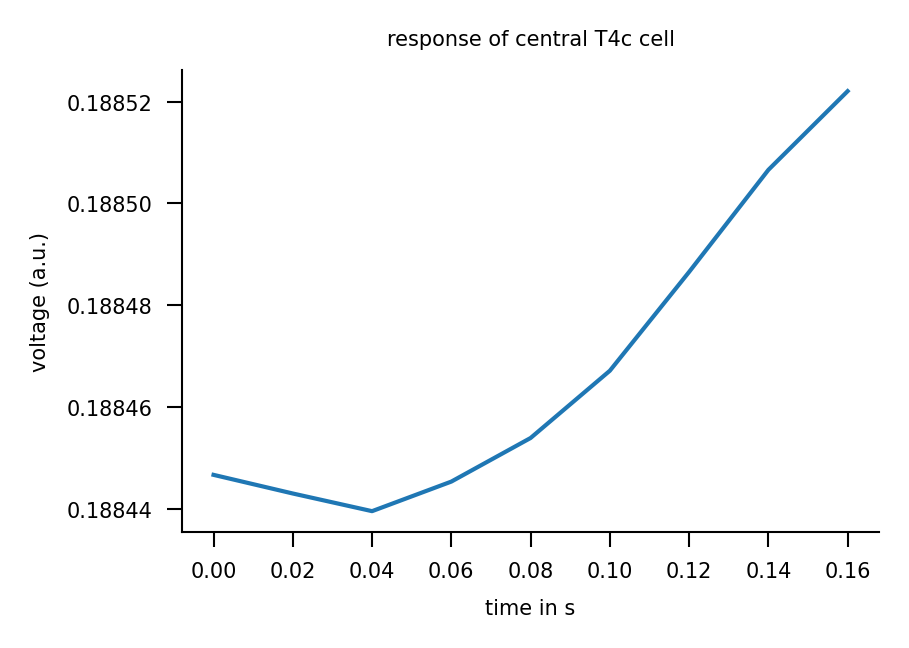

In [23]:
plt.figure(figsize=[3, 2])
layer_activity.update(responses)
r = layer_activity.central.T4c.squeeze().numpy()
time = np.arange(0, r.shape[0], 1) * dataset.dt
plt.plot(time, r)
plt.xlabel("time in s")
plt.ylabel("voltage (a.u.)")
plt.title("response of central T4c cell")

# Decoding the task from neural activity

We need to predict the pixel-accurate flow field that Sintel gives us. For that we decode the voltages of a bunch of cell types. The decoder and the network are trained end-to-end. Here an example of a forward pass through the whole pipeline in code.

In [24]:
from flyvis.datasets.sintel import MultiTaskSintel
from flyvis.task.decoder import DecoderGAVP

In [25]:
network = Network()

[2025-05-30 03:27:48] network:222 Initialized network with NumberOfParams(free=734, fixed=2959) parameters.


In [26]:
decoder = DecoderGAVP(network.connectome, shape=[8, 2], kernel_size=5)

[2025-05-30 03:27:52] decoder:282 Initialized decoder with NumberOfParams(free=7427, fixed=0) parameters.
[2025-05-30 03:27:52] decoder:283 DecoderGAVP(
  (base): Sequential(
    (0): Conv2dHexSpace(34, 8, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): Softplus(beta=1.0, threshold=20.0)
    (3): Dropout(p=0.5, inplace=False)
  )
  (decoder): Sequential(
    (0): Conv2dHexSpace(8, 3, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  )
  (head): Sequential()
)


In [ ]:
dataset = MultiTaskSintel(
    tasks=["flow"],
    boxfilter=dict(extent=15, kernel_size=13),
    vertical_splits=1,
    all_frames=True,
    dt=1 / 50,
    augment=False,
    resampling=True,
    interpolate=True,
)

In [27]:
data = dataset[0]
lum = data["rgb"]
flow = data["flow"]

stationary_state = network.fade_in_state(1.0, dataset.dt, lum[[0]])
responses = network.simulate(lum[None], dataset.dt, initial_state=stationary_state)

In [28]:
y_pred = decoder(responses)

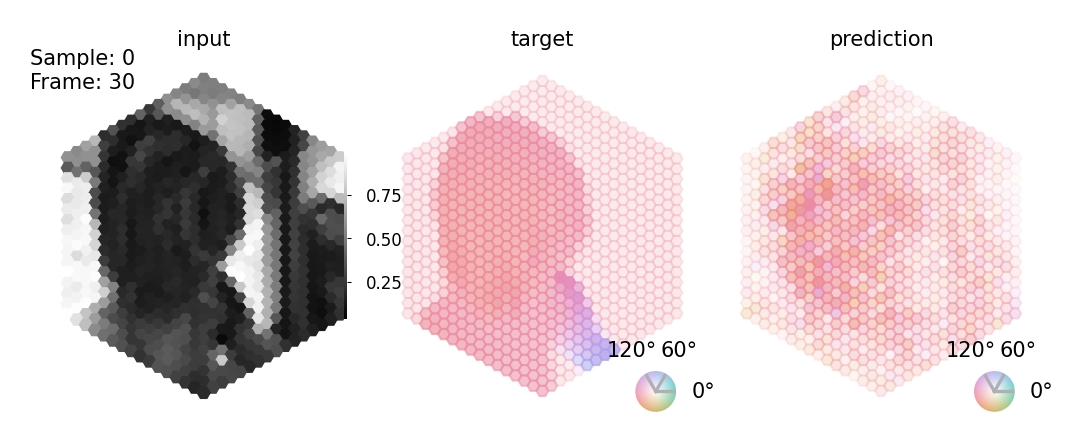

In [54]:
data = dataset[0]
lum = data["lum"]
flow = data["flow"]

stationary_state = network.fade_in_state(1.0, dataset.dt, lum[[0]])
responses = network.simulate(lum[None], dataset.dt, initial_state=stationary_state)
animation = SintelSample(lum[None], flow[None], prediction=y_pred.detach().cpu())
animation.animate_in_notebook(frames=np.arange(lum.shape[0])[::10])

We predict motion with an untrained decoder from an untrained network with randomly initialized parameters. 
We do not expect this to work.

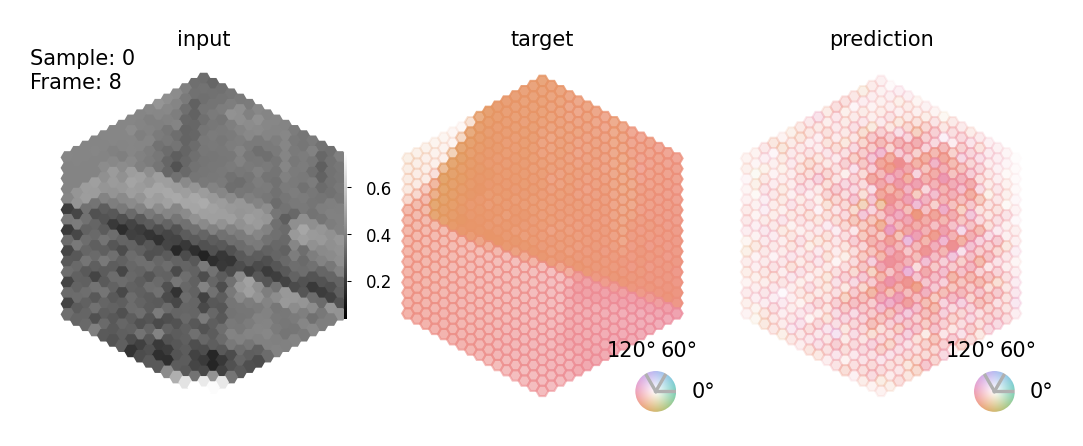

In [59]:
data = dataset1[0]
lum = data["rgb"]
flow = data["flow"]

stationary_state = network.fade_in_state(1.0, dataset.dt, lum[[0]])
responses = network.simulate(lum[None], dataset.dt, initial_state=stationary_state)
animation = SintelSample(lum[None], flow[None], prediction=y_pred.detach().cpu())
#animation.animate_in_notebook(frames=np.arange(lum.shape[0])[::10])
#animation = SintelSample(lum[None], flow[None])
animation.animate_in_notebook()

4522.9043


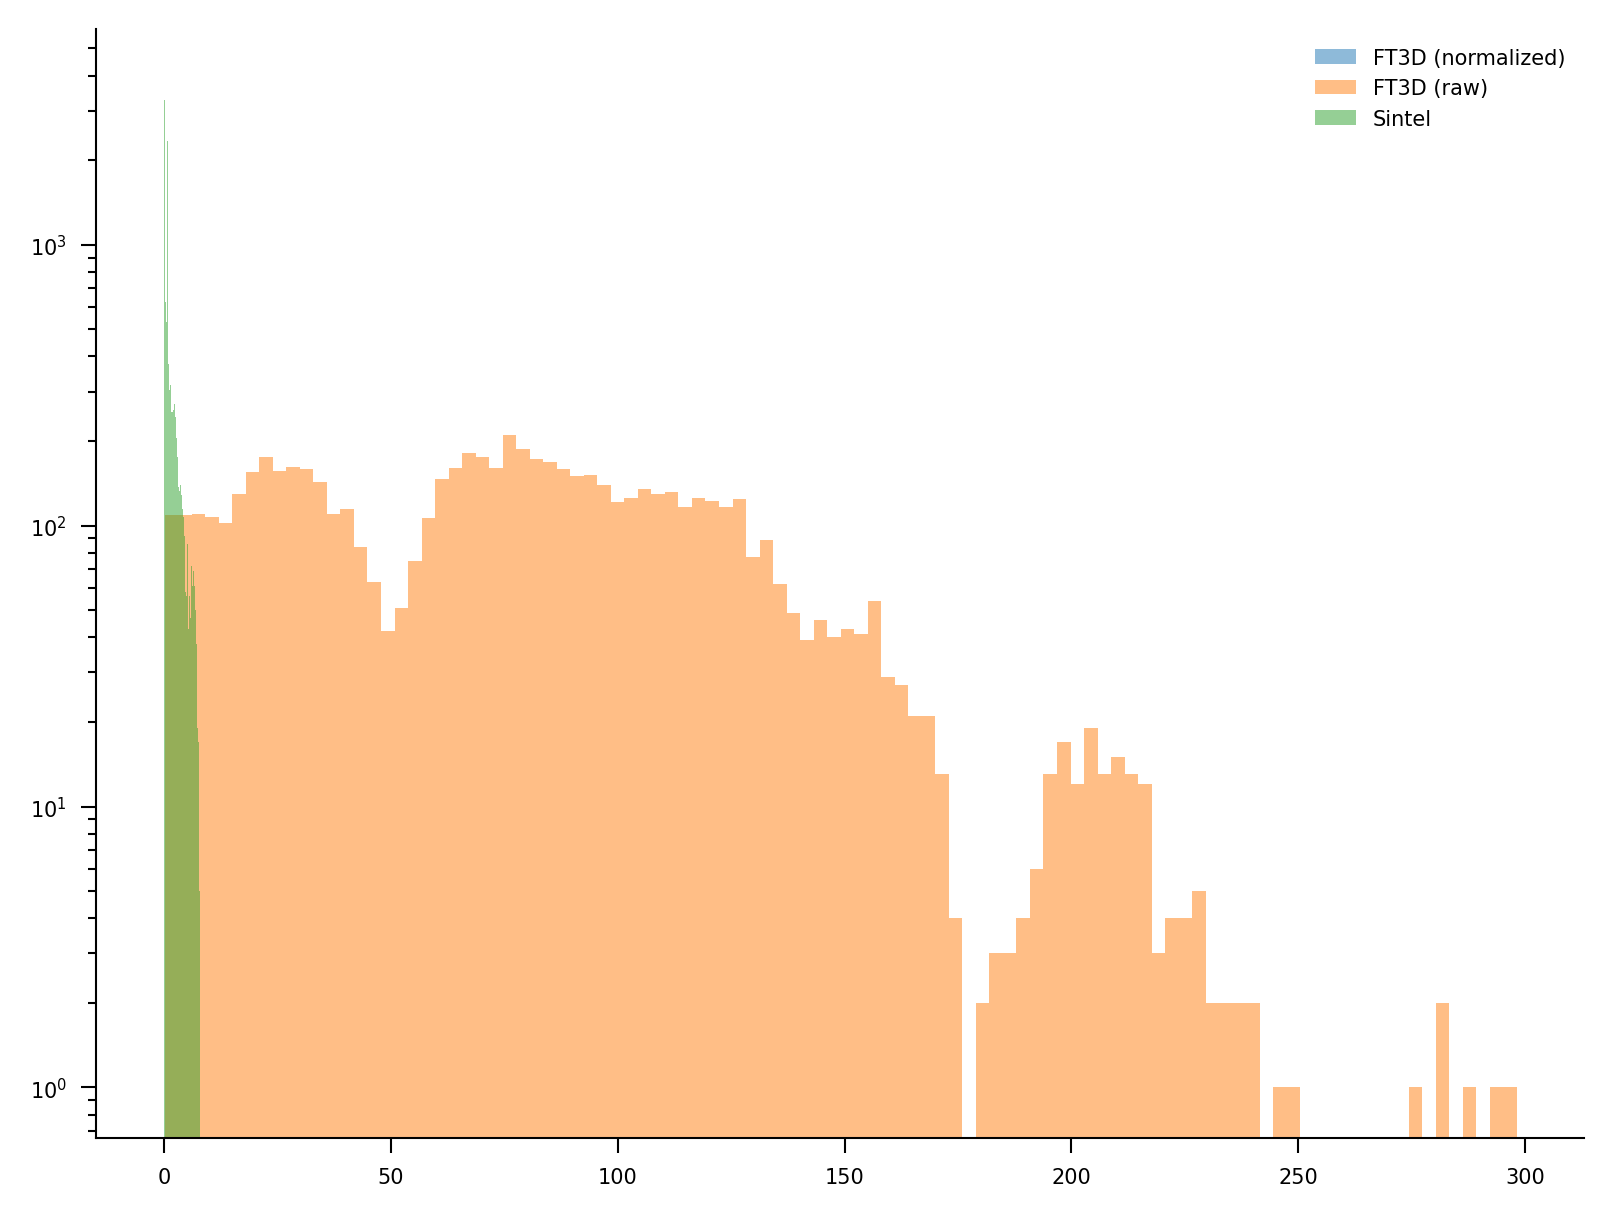

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def normalize_flow_tanh(flow: torch.Tensor, scale: float) -> torch.Tensor:
    return torch.tanh(flow / scale)

ft3d_flow   = dataset1[0]["flow"].cpu()
sintel_flow = dataset[0]["flow"].cpu()

# Raw magnitudes
mags_ft3d   = np.linalg.norm(ft3d_flow.reshape(-1, 2), axis=-1)
mags_sintel = np.linalg.norm(sintel_flow.reshape(-1, 2), axis=-1)

# Compute scale
p95_ft3d     = np.percentile(mags_ft3d, 95)
p95_sintel   = np.percentile(mags_sintel, 95)
target_ratio = p95_sintel / p95_ft3d
scale        = p95_ft3d / np.arctanh(target_ratio)
print()
# Apply normalization and get magnitudes
ft3d_flow_norm = normalize_flow_tanh(ft3d_flow, scale)
mags_ft3d_norm = np.linalg.norm(ft3d_flow_norm.reshape(-1, 2), axis=-1)

# Plot
plt.hist(mags_ft3d_norm, bins=100, alpha=0.5, label="FT3D (normalized)")
plt.hist(mags_ft3d,      bins=100, alpha=0.5, label="FT3D (raw)")
plt.hist(mags_sintel,    bins=100, alpha=0.5, label="Sintel")
plt.yscale("log")
plt.legend()
plt.show()


In [31]:
((y_pred - flow) ** 2).sqrt().mean()

tensor(53.9763, device='cuda:0', grad_fn=<MeanBackward0>)

# Training network and decoder on a single batch

We now train the network on a single batch to validate that the pipeline works. We do not expect these networks to generalize their function.

In [32]:
from tqdm.notebook import tqdm
from torch.optim import Adam
from torch.utils.data import DataLoader

from flyvis.network import Network
from flyvis.task.decoder import DecoderGAVP

from flyvis.datasets.sintel import MultiTaskSintel
from flyvis.task.objectives import l2norm, epe
from flyvis.connectome import *

In [33]:
from flyvis.network import Network
from datamate import Namespace

# 1) One parameter per node:
node_cfg = Namespace(
    bias=Namespace(
        type="RestingPotential",
        groupby=["type","index"],
        initial_dist="Normal", mode="sample",
        requires_grad=True, mean=0.5, std=0.05,
        penalize=Namespace(activity=True), seed=0,
    ),
    time_const=Namespace(
        type="TimeConstant",
        groupby=["type","index"],
        initial_dist="Value", value=0.05,
        requires_grad=True,
    ),
)

# 2) One parameter per edge:
edge_cfg = Namespace(
    sign=Namespace(
        type="SynapseSign",
        groupby=["source_type","target_type","source_index","target_index"],
        initial_dist="Value",
        requires_grad=False,
    ),
    syn_count=Namespace(
        type="SynapseCount",
        groupby=["source_type","target_type","source_index","target_index", "dv", "du"],
        initial_dist="Lognormal", mode="mean",
        requires_grad=True, std=1.0,
    ),
    syn_strength=Namespace(
        type="SynapseCountScaling",
        groupby=["source_type","target_type","source_index","target_index"],
        initial_dist="Value",
        requires_grad=True, scale=0.01,
        clamp="non_negative",
    ),
)

# 3) Build the network and check
net = Network(node_config=node_cfg, edge_config=edge_cfg)
print("free params:", net.num_parameters.free)
print("fixed params:", net.num_parameters.fixed)
for name, p in net.named_parameters():
    print(f"{name:20s} {p.numel():6d}")


[2025-05-30 03:28:57] network:222 Initialized network with NumberOfParams(free=3117800, fixed=1513231) parameters.


free params: 3117800
fixed params: 1513231
nodes_bias            45669
nodes_time_const      45669
edges_sign           1513231
edges_syn_count      1513231
edges_syn_strength   1513231


[2025-05-18 09:10:29] network:222 Initialized network with NumberOfParams(free=734, fixed=2959) parameters.


NODE fields: ['u', 'v', 'index', 'layer_index', 'type', 'role']
index: [0 1 2 3 4]
type:  [b'R1' b'R1' b'R1' b'R1' b'R1']
EDGE fields: ['target_u', 'du', 'source_type', 'n_syn', 'source_index', 'target_type', 'dv', 'sign', 'source_v', 'n_syn_certainty', 'target_index', 'target_v', 'source_u']
source_index: [0 1 2 3 4]
target_index: [5768 5769 5770 5771 5772]
source_type:  [b'R1' b'R1' b'R1' b'R1' b'R1']
target_type:  [b'L1' b'L1' b'L1' b'L1' b'L1']


In [17]:
net = Network()

[2025-05-17 23:27:05] network:222 Initialized network with NumberOfParams(free=734, fixed=2959) parameters.


In [3]:
decoder = DecoderGAVP(network.connectome, shape=[8, 2], kernel_size=5)

[2025-05-17 08:46:11] decoder:282 Initialized decoder with NumberOfParams(free=7427, fixed=0) parameters.
[2025-05-17 08:46:11] decoder:283 DecoderGAVP(
  (base): Sequential(
    (0): Conv2dHexSpace(34, 8, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): Softplus(beta=1.0, threshold=20.0)
    (3): Dropout(p=0.5, inplace=False)
  )
  (decoder): Sequential(
    (0): Conv2dHexSpace(8, 3, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  )
  (head): Sequential()
)


In [46]:
dataset = MultiTaskSintel(
    tasks=["flow"],
    boxfilter=dict(extent=15, kernel_size=13),
    vertical_splits=1,
    n_frames=19,
    dt=1 / 50,
    augment=False,
    resampling=True,
    interpolate=True,
)


[2025-05-30 03:31:46] sintel_utils:331 Found Sintel at /home/z/flyvis/data/SintelDataSet


In [ ]:
import numpy as np, matplotlib.pyplot as plt
mags_ft3d = np.linalg.norm(ft3d_flow.reshape(-1,2), axis=-1)
mags_sintel = np.linalg.norm(sintel_flow.reshape(-1,2), axis=-1)
plt.hist(mags_ft3d, bins=100, alpha=.5, label='FT3D')
plt.hist(mags_sintel, bins=100, alpha=.5, label='Sintel')
plt.yscale('log'); plt.legend(); plt.show()


In [47]:
t_pre = 0.5
dt = 1 / 50
batch_size = 4
train_loader = DataLoader(dataset, batch_size=batch_size)

In [48]:
optimizer = Adam((*network.parameters(), *decoder.parameters()), lr=1e-5)

In [49]:
batch = next(iter(train_loader))

In [50]:
loss_fn = epe

In [52]:
epochs = 1000

errors = []

initial_state = network.steady_state(t_pre, dt, batch_size)

for e in tqdm(range(epochs)):
    lum = batch["lum"]
    flow = batch["flow"]

    optimizer.zero_grad()
    network.stimulus.zero()
    network.stimulus.add_input(lum)

    activity = network(network.stimulus(), dt=1 / 50, state=initial_state)
    y_pred = decoder(activity)

    batch_error = loss_fn(y_pred, flow)
    errors.append(batch_error.cpu().item())
    batch_error.backward()
    optimizer.step()

    if e % 10 == 0:
        print(f"Epoch {e}: {batch_error.item()}")

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 0: 11.002737045288086
Epoch 10: 10.993096351623535
Epoch 20: 10.976489067077637
Epoch 30: 10.96190357208252
Epoch 40: 10.945511817932129
Epoch 50: 10.92741584777832
Epoch 60: 10.891759872436523
Epoch 70: 10.866890907287598
Epoch 80: 10.850654602050781
Epoch 90: 10.831010818481445
Epoch 100: 10.787933349609375
Epoch 110: 10.718092918395996
Epoch 120: 10.66719913482666
Epoch 130: 10.614883422851562
Epoch 140: 10.59593391418457
Epoch 150: 10.571385383605957
Epoch 160: 10.545984268188477
Epoch 170: 10.538643836975098
Epoch 180: 10.531393051147461
Epoch 190: 10.527463912963867
Epoch 200: 10.520589828491211
Epoch 210: 10.508711814880371
Epoch 220: 10.48513412475586
Epoch 230: 10.462646484375
Epoch 240: 10.451934814453125
Epoch 250: 10.447602272033691
Epoch 260: 10.44561767578125
Epoch 270: 10.444989204406738
Epoch 280: 10.442577362060547
Epoch 290: 10.438886642456055
Epoch 300: 10.43510913848877
Epoch 310: 10.431540489196777
Epoch 320: 10.431160926818848
Epoch 330: 10.426497459411621
E

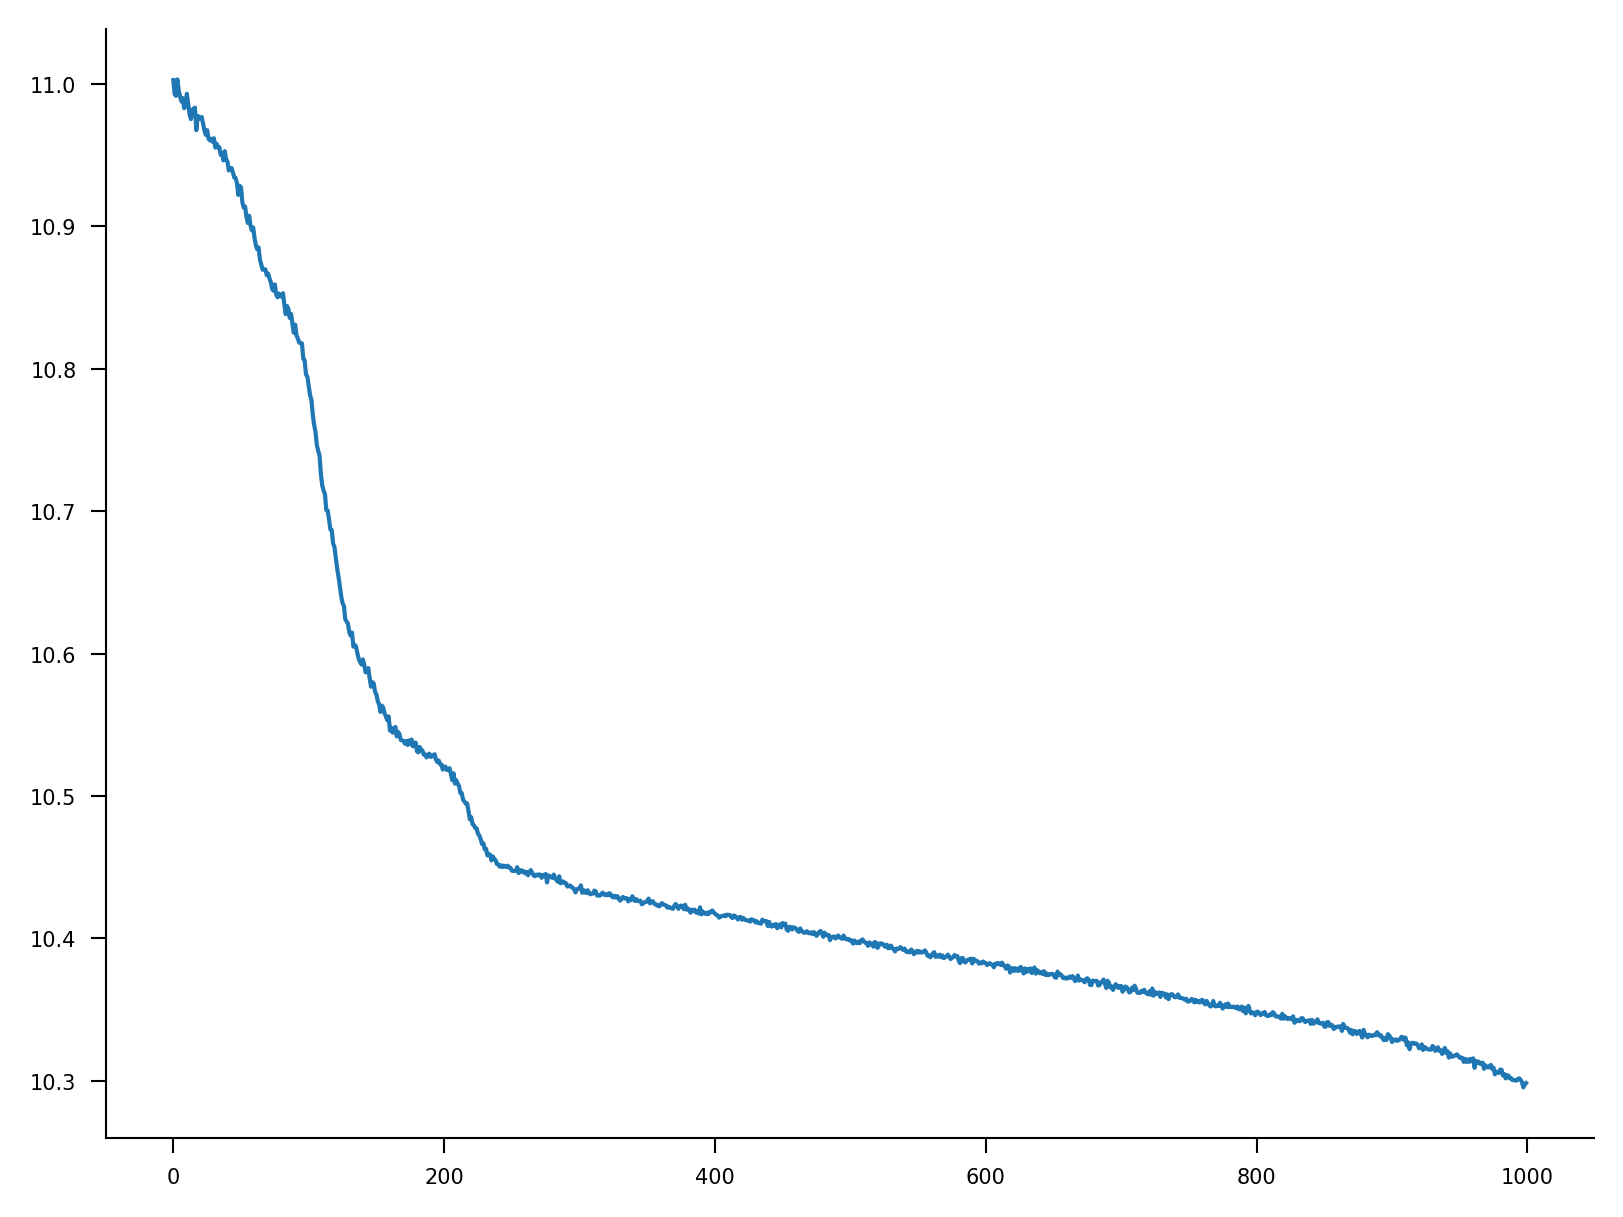

In [53]:
plt.plot(errors)

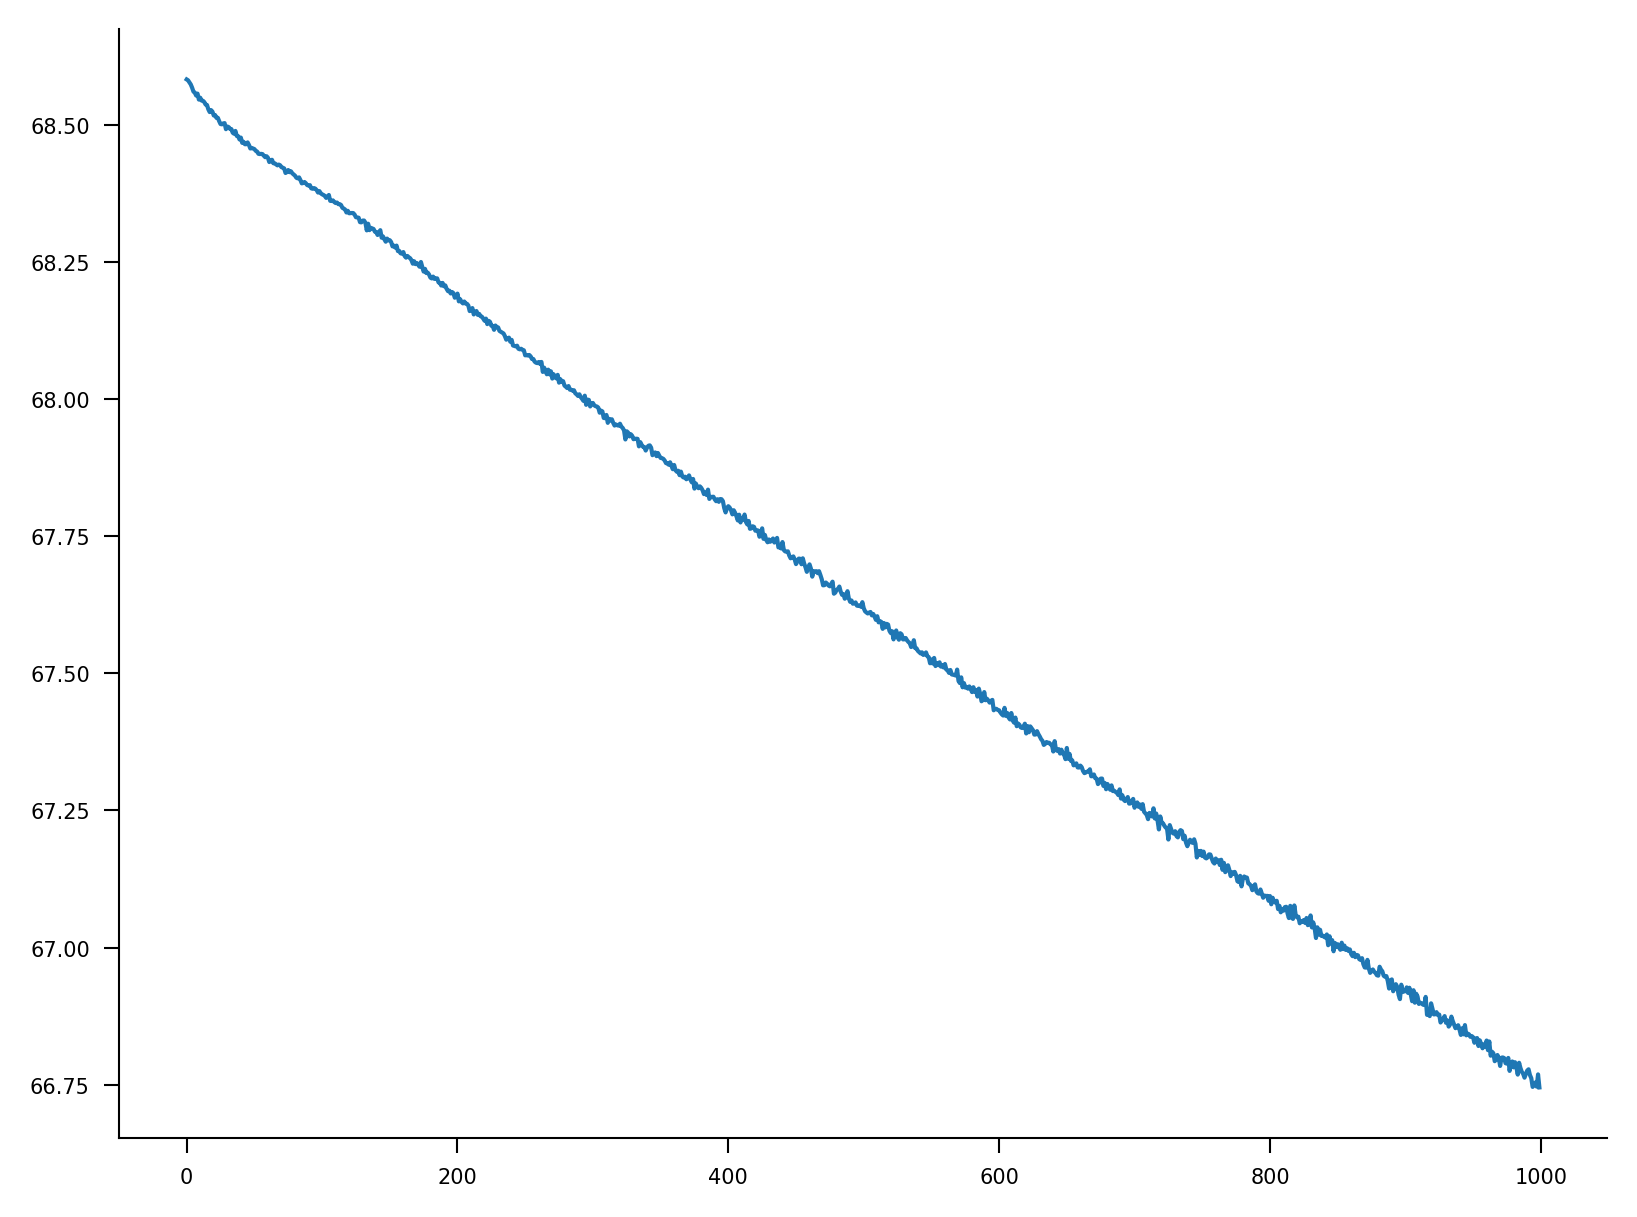

In [40]:
plt.plot(errors)

We expect that the prediction from this overfitted network on the sample it was trained on is ok.

In [42]:
data = dataset[0]
lum = data["rgb"]
flow = data["flow"]

stationary_state = network.fade_in_state(1.0, dataset.dt, lum[[0]])
responses = network.simulate(lum[None], dataset.dt, initial_state=stationary_state)

In [43]:
y_pred = decoder(responses)

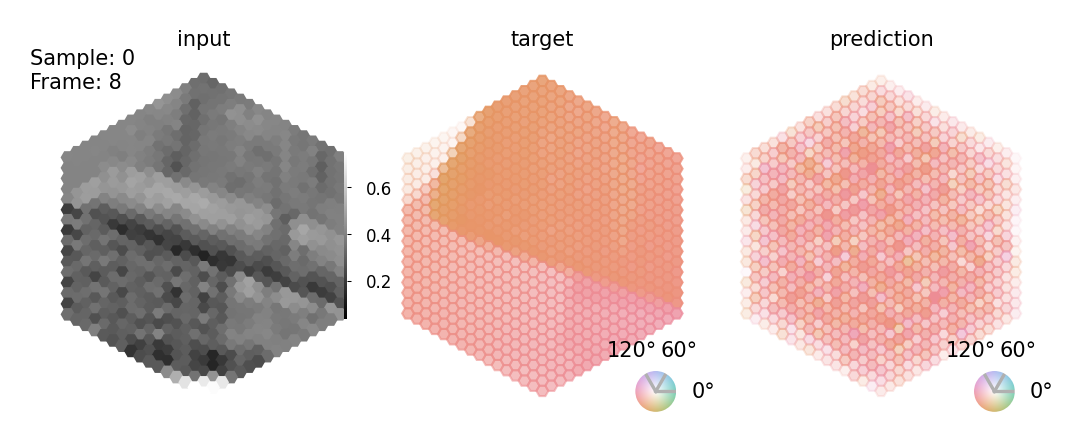

In [44]:
animation = SintelSample(lum[None], flow[None], prediction=y_pred.detach().cpu())
animation.animate_in_notebook()

In [45]:
((y_pred - flow) ** 2).sqrt().mean()

tensor(52.9297, device='cuda:0', grad_fn=<MeanBackward0>)

# Evaluating trained networks

In [ ]:
from flyvis import results_dir
from flyvis.network import NetworkView
from flyvis.utils.activity_utils import LayerActivity

from flyvis.datasets.sintel import MultiTaskSintel
from flyvis.task.decoder import DecoderGAVP

In [ ]:
# we load the best task-performing model from the presorted ensemble
network_view = NetworkView(results_dir / "flow/0000/000")

In [ ]:
network = network_view.init_network()

In [ ]:
network_view.dir.config.task.decoder

In [ ]:
decoder = network_view.init_decoder()["flow"]

In [ ]:
dataset = MultiTaskSintel(
    tasks=["flow"],
    boxfilter=dict(extent=15, kernel_size=13),
    vertical_splits=1,
    all_frames=False,
    n_frames=19,
    dt=1 / 50,
    augment=False,
    resampling=True,
    interpolate=True,
)

In [ ]:
data = [dataset[i] for i in range(4)]
lum = torch.stack([d["lum"] for d in data])
flow = torch.stack([d["flow"] for d in data])

stationary_state = network.fade_in_state(1.0, dataset.dt, lum[:, 0])
responses = network.simulate(lum, dataset.dt, initial_state=stationary_state)

In [ ]:
y_pred = decoder(responses)

We expect this network to generalize across sequences. This network sees motion into all directions.

In [ ]:
animation = SintelSample(lum, flow, prediction=y_pred.detach().cpu())
animation.animate_in_notebook()

We expect the accuracy is not as good as the overfitted example because this network generalized across the whole-dataset.

In [ ]:
((y_pred - flow) ** 2).sqrt().mean()

# Evaluating ensembles

Last, we evaluated the task error of the 50 trained networks on a held out set of sequences. We evaluated the task error across all checkpoints during training and show the minimal one in the histrogram below. This checkpoint we analyse with respect to it's tuning predictions as shown in the next notebooks.

In [2]:
from flyvis import EnsembleView

In [1]:
ensemble = EnsembleView("flow/0000")

NameError: name 'EnsembleView' is not defined

In [ ]:
ensemble.task_error_histogram()